### Download dataset (raw) to inspect

In [25]:
import torch
from torch_geometric.datasets import ModelNet
from torch_geometric import data

In [71]:
# ModelNet10 Categories sorted alphabetically
categories = [
    'bathtub', 'bed', 'chair', 'desk', 'dresser', 
    'monitor', 'night_stand', 'sofa', 'table', 'toilet'
]

In [12]:

dataset = ModelNet(root='data/ModelNet_Raw',
                    name='10', # for ModelNet10 (10 classes)
                    train=False,
                    transform=None, # runs On the fly, every single time a specific object is loaded into a batch during training.
                    pre_transform=None) # runs Only once, the very first time you download or process the dataset

In [59]:
len(dataset)

908

### Mesh data format

1. `mesh_data.pos`: The 3D coordinates of the original vertices. Shape is [num_vertices, 3]
2. `mesh_data.face`: The connectivity matrix defining the triangles. Shape is [3, num_faces], where each column contains 3 vertex indices that form a triangle.
3. `mesh_data.y`: The class label (e.g., table, chair) as an integer

len(dataset), dataset[0]

In [21]:
dataset[1]

Data(pos=[96750, 3], face=[3, 122855], y=[1])

In [31]:
assert type(dataset[0]) == data.Data

### Convert mesh data to point clouds
To convert a 3D mesh into a point cloud, the SamplePoints(N) transformation uses a process 
called surface area sampling. It doesn't just pick existing corner dots; it generates completely new points 
right on the faces of the triangles.
In our example we use `N=512`

In [32]:
import torch_geometric.transforms as transforms

In [86]:
sample_transform = transforms.Compose([
    transforms.SamplePoints(num=1024),
])

In [87]:
point_clouds = sample_transform(dataset[200])
point_clouds.pos.shape, point_clouds.face, point_clouds.y

(torch.Size([1024, 3]), None, tensor([2]))

In [88]:
point_clouds.pos[:10]

tensor([[ -6.3249,   5.4015,   1.0626],
        [  6.8655,   2.2933,   2.5657],
        [ -4.3117,   9.8552,  16.7895],
        [  9.9637, -11.2447,  -2.2985],
        [  0.0804,   7.7183,   9.7881],
        [ -9.1876,   4.2439,   1.1228],
        [ -1.3024,   2.0776,   2.4357],
        [  9.5725, -10.1355, -13.4138],
        [ -7.9624,   8.3221,  12.6164],
        [  9.2076, -11.2929,  -9.3305]])

In [89]:
sample_transform2 = transforms.Compose([
    transforms.NormalizeScale(), # between [-1, 1]
])

In [90]:
point_clouds = sample_transform2(point_clouds)

In [91]:
point_clouds.pos.shape, point_clouds.face, point_clouds.y

(torch.Size([1024, 3]), None, tensor([2]))

In [92]:
point_clouds.pos[:10], point_clouds.y

(tensor([[-0.2998,  0.2266, -0.1021],
         [ 0.3500,  0.0735, -0.0280],
         [-0.2006,  0.4459,  0.6726],
         [ 0.5026, -0.5934, -0.2676],
         [ 0.0158,  0.3407,  0.3277],
         [-0.4408,  0.1695, -0.0991],
         [-0.0524,  0.0628, -0.0344],
         [ 0.4833, -0.5388, -0.8151],
         [-0.3804,  0.3704,  0.4671],
         [ 0.4653, -0.5958, -0.6140]]),
 tensor([2]))

### Tranform the whole raw dataset into point clouds

In [93]:
test_data_point_clouds = [sample_transform2(sample_transform(mesh_data)) for mesh_data in dataset]

In [94]:
len(test_data_point_clouds), test_data_point_clouds[800], test_data_point_clouds[800].pos, test_data_point_clouds[800].y

(908,
 Data(pos=[1024, 3], y=[1]),
 tensor([[-0.5284, -0.8759, -0.6803],
         [-0.2682,  0.1254,  0.2857],
         [-0.3269,  0.6170,  0.2551],
         ...,
         [ 0.3697, -0.1102,  0.2857],
         [ 0.1405, -0.8365,  0.2230],
         [ 0.3897, -0.6139,  0.2857]]),
 tensor([8]))

### Visualize 3D point clouds

In [95]:
import matplotlib.pyplot as plt

In [121]:
idx = int(torch.randint(low=0, high=len(test_data_point_clouds), size=()).item())

In [122]:
point_cloud_sample = test_data_point_clouds[idx].pos
label = test_data_point_clouds[idx].y
point_cloud_sample.shape

torch.Size([1024, 3])

In [123]:
x = point_cloud_sample[:, 0]
y = point_cloud_sample[:, 1]
z = point_cloud_sample[:, 2]

In [124]:
t = dataset[0]
t.pos.shape, t.face.T.shape, t.y

(torch.Size([703, 3]), torch.Size([1008, 3]), tensor([0]))

In [125]:
# Extract data for mesh
mesh_data = dataset[idx]
mesh_vertices = mesh_data.pos
mesh_faces = mesh_data.face.numpy().T
mesh_labels = mesh_data.y.item()

mesh_x = mesh_vertices[:, 0]
mesh_y = mesh_vertices[:, 1]
mesh_z = mesh_vertices[:, 2]

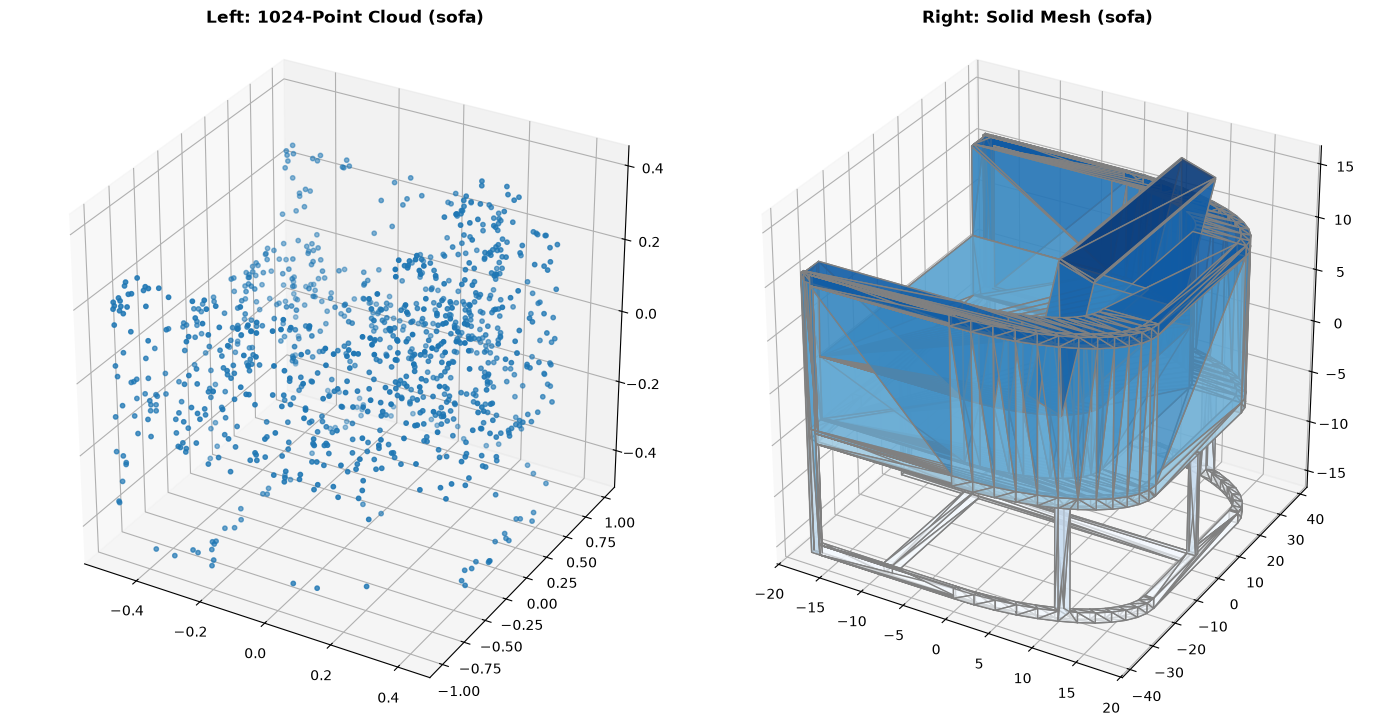

In [129]:
# create a 3d scatter plot
fig = plt.figure(figsize=(14, 7))

# point cloud
ax = fig.add_subplot(1, 2, 1, projection="3d") # nrows, ncols, index
ax.scatter(x, y, z, s=10)
ax.set_box_aspect([1, 1, 1])  # CRITICAL: Stops the object from distorting/squishing
ax.set_title(f"Left: 1024-Point Cloud ({categories[label]})", fontsize=12, fontweight='bold')

# mesh
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_trisurf(mesh_x, mesh_y, mesh_z, 
                 triangles=mesh_faces, cmap='Blues', edgecolor='gray', alpha=0.7)
ax2.set_title(f"Right: Solid Mesh ({categories[mesh_labels]})", fontsize=12, fontweight='bold')
ax2.set_box_aspect([1,1,1])  # Keep 1:1:1 aspect ratio

plt.tight_layout()
plt.show()

### Generate synthetic dataset for point cloud

In [135]:
# Generate a solid cube
def generate_cube(num_points: int, 
                  side_length: float = 1., 
                  center: torch.Tensor = torch.tensor([0.,0.,0.]), 
                  generator: torch.Generator | None = None):
    """Generate a solid cube point cloud"""
    points = torch.rand(size=(num_points, 3), 
                        generator=generator, 
                        dtype=torch.float32) # [N, 3] generates between 0., 1.
    # scale it as per the side length
    points = points * side_length
    # shift as per center
    points = points + center - (side_length / 2)
    return points # [N, 3]

In [153]:
sample_cube1 = generate_cube(1024, side_length=2.4)
sample_cube2 = generate_cube(1024, side_length=1.6)

In [154]:
x1 = sample_cube1[:, 0].numpy()
y1 = sample_cube1[:, 1].numpy()
z1 = sample_cube1[:, 2].numpy()

x2 = sample_cube2[:, 0].numpy()
y2 = sample_cube2[:, 1].numpy()
z2 = sample_cube2[:, 2].numpy()

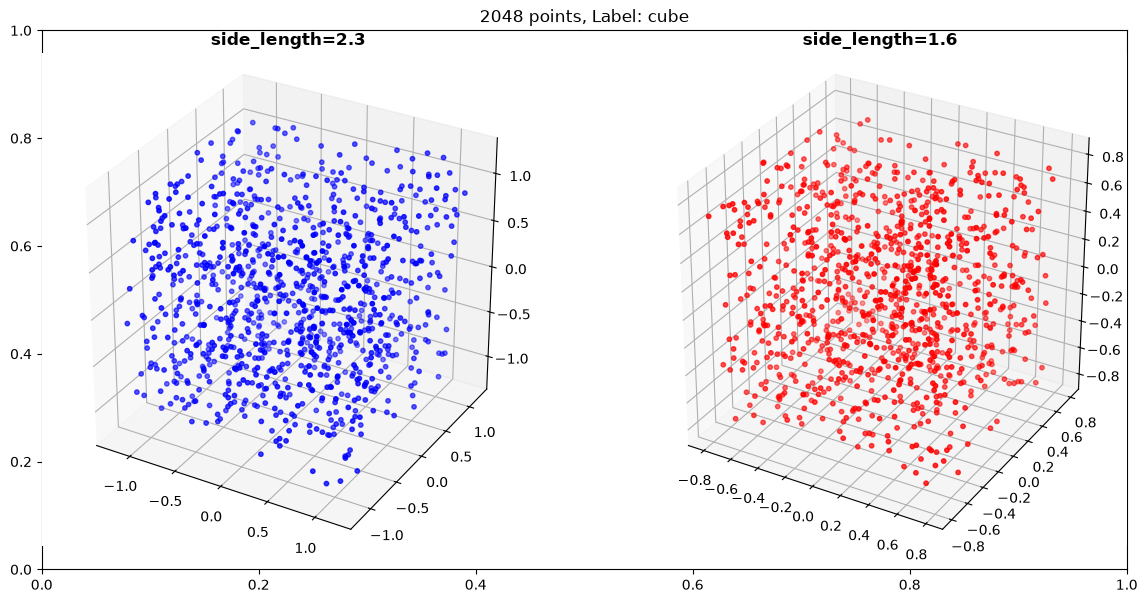

In [155]:
# create a 3d scatter plot

fig = plt.figure(figsize=(14, 7))
plt.title("2048 points, Label: cube")

# cube 1 point cloud
ax = fig.add_subplot(1, 2, 1, projection="3d") # nrows, ncols, index
ax.scatter(x1, y1, z1, s=10, color='blue')
ax.set_box_aspect([1, 1, 1])  # CRITICAL: Stops the object from distorting/squishing
ax.set_title(f"side_length=2.3", fontsize=12, fontweight='bold')

# cube 2 point cloud
ax = fig.add_subplot(1, 2, 2, projection="3d") # nrows, ncols, index
ax.scatter(x2, y2, z2, s=10, color='red')
ax.set_box_aspect([1, 1, 1])  # CRITICAL: Stops the object from distorting/squishing
ax.set_title(f"side_length=1.6", fontsize=12, fontweight='bold')

plt.show()

### Visualize normalized sphere, cube and cylinder

In [168]:
from pathlib import Path
import sys

current_dir = Path.cwd()
root_dir = None

for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'src').is_dir():
        root_dir = parent
        break

if root_dir and str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
    print(f"Added to path: {root_dir}")
elif not root_dir:
    print("Could not find the root directory containing 'src'!")

Added to path: /Users/admin/ml-engineering-projects-lab


In [173]:
from src.data.synthetic_shapes import SyntheticPointCloudDataset, CLASS_IDX_TO_LABEL
from src.data.transforms import normalize_point_cloud

In [182]:
raw_dataset = SyntheticPointCloudDataset(num_samples=300,
                                          points_per_shape=512,
                                          seed=42,
                                          transform=None)
normalized_dataset = SyntheticPointCloudDataset(num_samples=300,
                                            points_per_shape=512,
                                            seed=42,
                                            transform=normalize_point_cloud)

In [185]:
# create a 3d scatter plot
def visualize_raw_and_normalized_point_clouds(raw_points: torch.Tensor, 
              normalized_points: torch.Tensor, 
              label: torch.Tensor):
    x1 = raw_points[:, 0].numpy()
    y1 = raw_points[:, 1].numpy()
    z1 = raw_points[:, 2].numpy()
    x2 = normalized_points[:, 0].numpy()
    y2 = normalized_points[:, 1].numpy()
    z2 = normalized_points[:, 2].numpy()
    fig = plt.figure(figsize=(14, 7))
    plt.title(f"2048 points, Label: {CLASS_IDX_TO_LABEL[int(label.item())]}")

    # cube 1 point cloud
    ax = fig.add_subplot(1, 2, 1, projection="3d") # nrows, ncols, index
    ax.scatter(x1, y1, z1, s=10, color='blue')
    ax.set_box_aspect([1, 1, 1])  # CRITICAL: Stops the object from distorting/squishing
    ax.set_title(f"raw_points", fontsize=12, fontweight='bold')

    # cube 2 point cloud
    ax = fig.add_subplot(1, 2, 2, projection="3d") # nrows, ncols, index
    ax.scatter(x2, y2, z2, s=10, color='red')
    ax.set_box_aspect([1, 1, 1])  # CRITICAL: Stops the object from distorting/squishing
    ax.set_title(f"normalized_points", fontsize=12, fontweight='bold')

    plt.show()

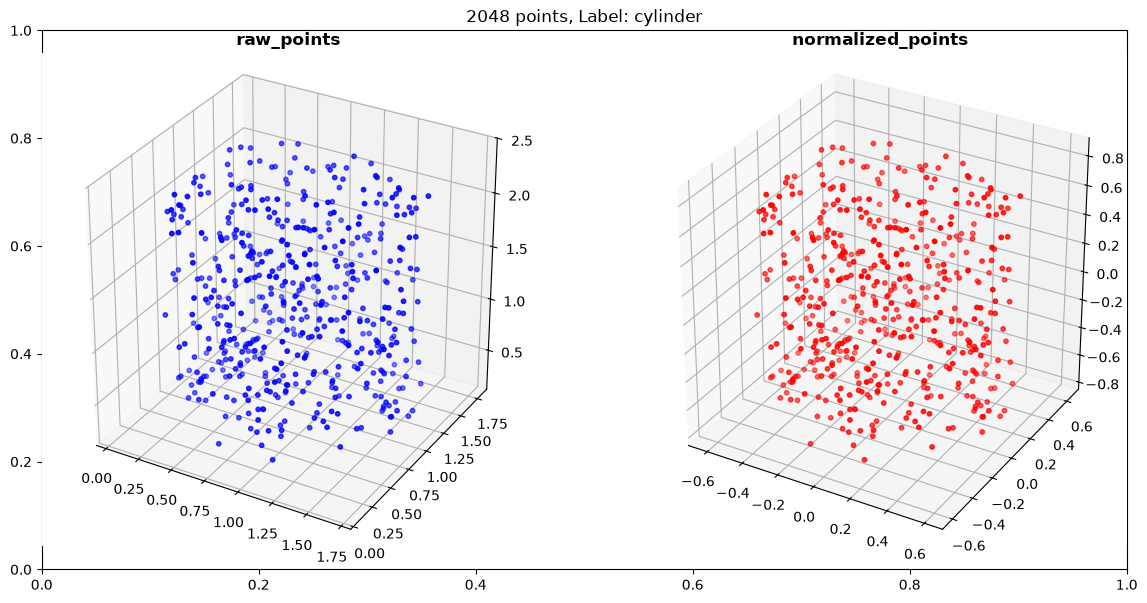

In [201]:
raw_points, raw_label = raw_dataset[2]
normalized_points, normalized_label = normalized_dataset[2]
visualize_raw_and_normalized_point_clouds(raw_points, normalized_points, raw_label)

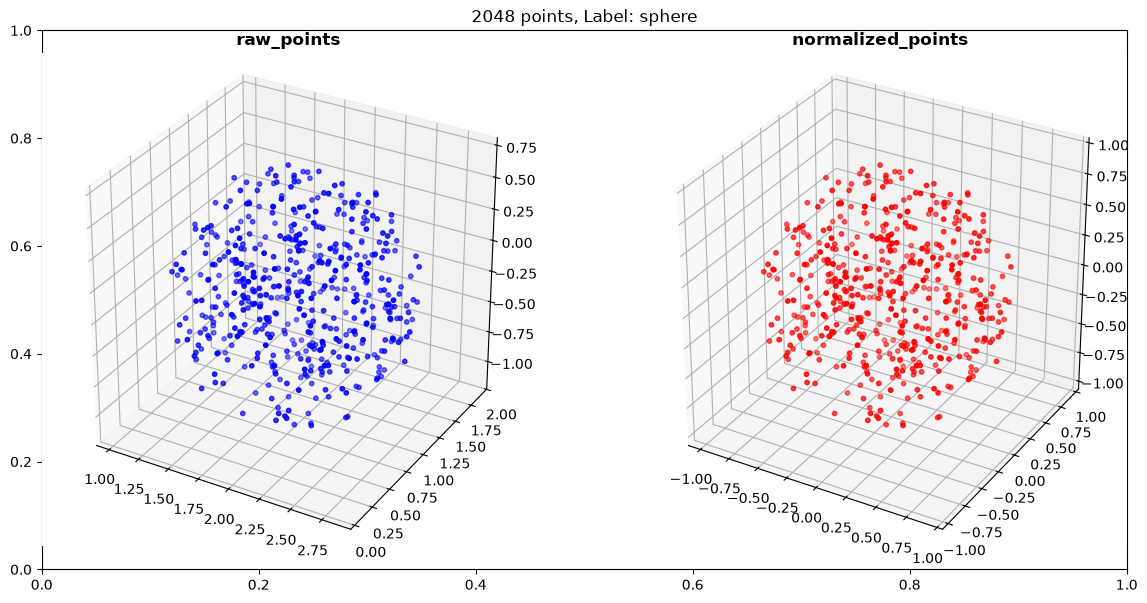

In [197]:
raw_points, raw_label = raw_dataset[9]
normalized_points, normalized_label = normalized_dataset[9]
visualize_raw_and_normalized_point_clouds(raw_points, normalized_points, raw_label)

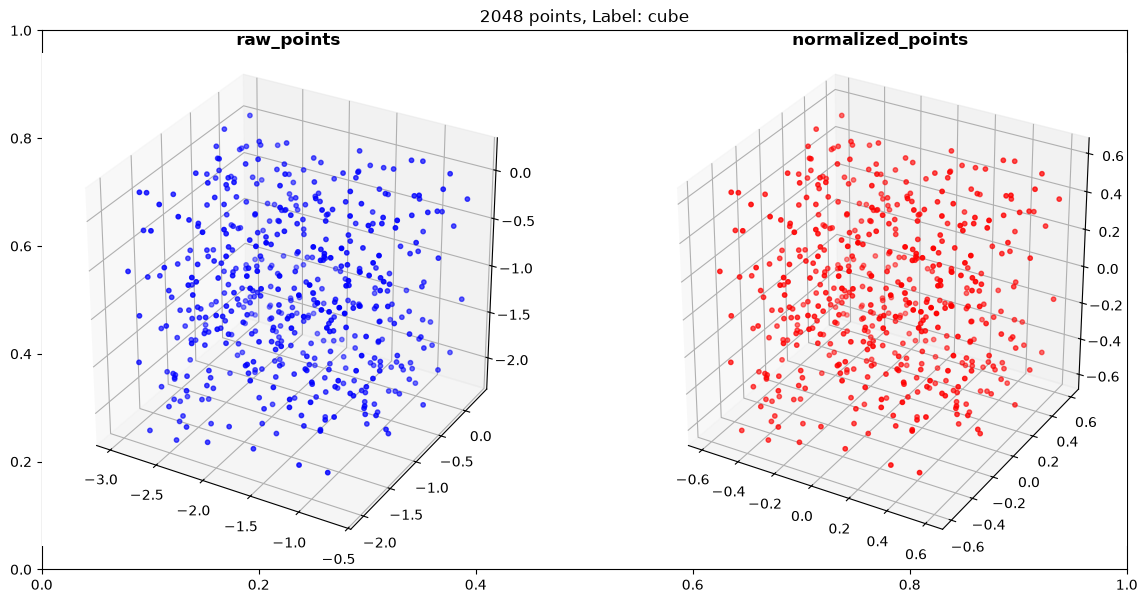

In [200]:
raw_points, raw_label = raw_dataset[7]
normalized_points, normalized_label = normalized_dataset[7]
visualize_raw_and_normalized_point_clouds(raw_points, normalized_points, raw_label)